In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from scipy.fftpack import dct, idct
# Metrik kualitas gambar
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

In [2]:
# Konfigurasi
INPUT_FOLDER = "dataset"
OUTPUT_FOLDER = "output"
RESULTS_FOLDER = "results"
DEFAULT_QUALITY = 50
QUALITY_LEVELS = [10, 30, 50, 70, 90]
SUPPORTED_EXT = {'.jpeg', '.jpg'}

# Buat folder output
for folder in [OUTPUT_FOLDER, RESULTS_FOLDER]:
    os.makedirs(folder, exist_ok=True)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving gambar1.jpeg to gambar1.jpeg
Saving gambar2.jpeg to gambar2.jpeg
Saving gambar3.jpeg to gambar3.jpeg
Saving gambar4.jpeg to gambar4.jpeg
Saving gambar5.jpeg to gambar5.jpeg
Saving gambar6.jpeg to gambar6.jpeg
Saving gambar7.jpeg to gambar7.jpeg
Saving gambar8.jpeg to gambar8.jpeg
Saving gambar9.jpeg to gambar9.jpeg
Saving gambar10.jpeg to gambar10.jpeg
Saving gambar11.jpeg to gambar11.jpeg
Saving gambar12.jpeg to gambar12.jpeg
Saving gambar13.jpeg to gambar13.jpeg
Saving gambar14.jpeg to gambar14.jpeg
Saving gambar15.jpeg to gambar15.jpeg
Saving gambar16.jpeg to gambar16.jpeg
Saving gambar17.jpeg to gambar17.jpeg
Saving gambar18.jpeg to gambar18.jpeg
Saving gambar19.jpeg to gambar19.jpeg
Saving gambar20.jpeg to gambar20.jpeg


## **Implementasi Manual Algoritma DCT**

In [4]:
# =========================================
# QUANTIZATION TABLE JPEG
# =========================================

"""
Tabel kuantisasi standar JPEG (luminance).

Fungsi:
- menentukan seberapa besar informasi frekuensi dibuang
- semakin besar nilai tabel → kompresi semakin agresif
- bagian ini merupakan inti dari kompresi lossy JPEG
"""

Q_LUMINANCE = np.array([
    [16, 11, 10, 16,  24,  40,  51,  61],
    [12, 12, 14, 19,  26,  58,  60,  55],
    [14, 13, 16, 24,  40,  57,  69,  56],
    [14, 17, 22, 29,  51,  87,  80,  62],
    [18, 22, 37, 56,  68, 109, 103,  77],
    [24, 35, 55, 64,  81, 104, 113,  92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103,  99]
])

print("[OK] Quantization Table berhasil dibuat")

[OK] Quantization Table berhasil dibuat


In [5]:
# =========================================
# Membuat FUNGSI 2D-DCT
# =========================================

from scipy.fftpack import dct, idct

def dct2(block):

    """
    Melakukan transformasi DCT 2 dimensi.

    Fungsi:
    mengubah data gambar dari:
    - domain spasial (pixel)

    menjadi:
    - domain frekuensi
    """

    return dct(dct(block.T, norm='ortho').T, norm='ortho')

print("[OK] Fungsi DCT berhasil dibuat")

[OK] Fungsi DCT berhasil dibuat


In [6]:
# =========================================
# Membuat FUNGSI INVERSE DCT
# =========================================

def idct2(block):

    """
    Inverse DCT digunakan untuk:
    mengembalikan data frekuensi
    menjadi gambar kembali.
    """

    return idct(idct(block.T, norm='ortho').T, norm='ortho')

print("[OK] Fungsi Inverse DCT berhasil dibuat")

[OK] Fungsi Inverse DCT berhasil dibuat


In [7]:
# =========================================
# Membuat QUALITY SCALING
# =========================================

def get_q_table(quality=50):

    """
    Mengatur tingkat kualitas JPEG.

    Quality kecil:
    - kompresi lebih agresif
    - ukuran file lebih kecil
    - kualitas menurun

    Quality besar:
    - kualitas lebih bagus
    - ukuran file lebih besar
    """

    if quality < 50:
        scale = 5000 / quality
    else:
        scale = 200 - 2 * quality

    q_table = np.floor((Q_LUMINANCE * scale + 50) / 100)

    q_table[q_table < 1] = 1

    return q_table

print("[OK] Quality scaling berhasil dibuat")

[OK] Quality scaling berhasil dibuat


In [8]:
# =========================================
# Implementasi KOMPRESI BLOK 8x8
# =========================================

def compress_channel(channel, q_table):

    """
    Kompresi DCT pada satu channel warna.

    Tahapan JPEG:

    1. Membagi gambar menjadi blok 8x8
    2. Subtract 128 (centering)
    3. Forward DCT
    4. Quantization  ← tahap LOSSY utama
    5. Dequantization
    6. Inverse DCT
    """

    h, w = channel.shape

    output = np.zeros_like(channel, dtype=np.float64)

    # proses per blok 8x8
    for i in range(0, h, 8):
        for j in range(0, w, 8):

            # mengambil blok 8x8
            block = channel[i:i+8, j:j+8].astype(np.float64) - 128

            # =========================================
            # FORWARD DCT
            # =========================================

            dct_block = dct2(block)

            # =========================================
            # QUANTIZATION
            # INTI LOSSY COMPRESSION
            # =========================================

            quantized = np.round(dct_block / q_table)

            """
            Pada tahap ini:
            - detail kecil dibuang
            - ukuran file mengecil
            """

            # =========================================
            # DEQUANTIZATION
            # =========================================

            dequantized = quantized * q_table

            # =========================================
            # INVERSE DCT
            # =========================================

            output[i:i+8, j:j+8] = idct2(dequantized) + 128

    return output

print("[OK] Fungsi kompresi channel berhasil dibuat")

[OK] Fungsi kompresi channel berhasil dibuat


In [ ]:
## 3. Batch JPEG Compression
#
# Pada bagian ini, semua gambar dalam dataset dikompresi menggunakan
# library PIL (yang menggunakan DCT secara internal via `libjpeg`).
#
# Setiap gambar dikompresi dengan `quality=50` dan disimpan ke folder output.

# %%
# =========================================
# BATCH KOMPRESI JPEG (SEMUA GAMBAR)
# =========================================

print("=" * 55)
print("  PROSES KOMPRESI DCT JPEG — BATCH PROCESSING")
print("=" * 55)

compression_log = []  # Menyimpan log waktu kompresi

for filename in sorted(os.listdir(INPUT_FOLDER)):
    if Path(filename).suffix.lower() not in SUPPORTED_EXT:
        continue

    input_path = os.path.join(INPUT_FOLDER, filename)
    out_name = f"compressed_{Path(filename).stem}.jpg"
    output_path = os.path.join(OUTPUT_FOLDER, out_name)

    try:
        start_time = time.time()

        # Baca dan konversi ke RGB (JPEG membutuhkan mode RGB)
        image = Image.open(input_path).convert("RGB")

        # Simpan sebagai JPEG dengan DCT compression (via libjpeg)
        image.save(output_path, "JPEG", optimize=True, quality=DEFAULT_QUALITY)

        elapsed = time.time() - start_time
        compression_log.append({
            "Image": filename,
            "Time (s)": round(elapsed, 3)
        })
        print(f"  [OK] {filename:25s} ({elapsed:.3f}s)")

    except Exception as e:
        print(f"  [ERROR] {filename} -> {e}")

print(f"\nTotal: {len(compression_log)} gambar berhasil dikompresi.")


## **KOMPRESI JPEG (SEMUA GAMBAR)**

In [23]:
 ## 3. Batch JPEG Compression
#
# Pada bagian ini, semua gambar dalam dataset dikompresi menggunakan
# library PIL (yang menggunakan DCT secara internal via `libjpeg`).
#
# Setiap gambar dikompresi dengan `quality=50` dan disimpan ke folder output.

# %%
# =========================================
# BATCH KOMPRESI JPEG MENGGUNAKAN DCT MANUAL
# =========================================
# Setiap gambar dikompresi menggunakan fungsi dct_compress_image()
# yang sudah kita implementasikan di atas.
#
# Alur per gambar:
#   1. Baca gambar → convert RGB
#   2. Kompresi DCT manual (block 8x8 → DCT → Quantize → IDCT)
#   3. Simpan hasil ke file JPEG

print("=" * 55)
print("  PROSES KOMPRESI DCT JPEG — BATCH PROCESSING")
print("=" * 55)

compression_log = []

for filename in sorted(os.listdir(INPUT_FOLDER)):
    if Path(filename).suffix.lower() not in SUPPORTED_EXT:
        continue

    input_path = os.path.join(INPUT_FOLDER, filename)
    out_name = f"compressed_{Path(filename).stem}.jpg"
    output_path = os.path.join(OUTPUT_FOLDER, out_name)

    try:
        start_time = time.time()

        # ===== LANGKAH 1: Baca gambar =====
        image = Image.open(input_path).convert("RGB")
        img_array = np.array(image)

        # ===== LANGKAH 2: Kompresi DCT Manual =====
        # Fungsi ini melakukan: split 8x8 → DCT → Quantization → IDCT
        compressed_array = dct_compress_image(img_array, quality=DEFAULT_QUALITY)

        # ===== LANGKAH 3: Simpan hasil ke file JPEG =====
        compressed_image = Image.fromarray(compressed_array)
        compressed_image.save(output_path, "JPEG", quality=95)

        elapsed = time.time() - start_time
        compression_log.append({
            "Image": filename,
            "Time (s)": round(elapsed, 3)
        })
        print(f"  [OK] {filename:25s} ({elapsed:.3f}s)")

    except Exception as e:
        print(f"  [ERROR] {filename} -> {e}")

print(f"\nTotal: {len(compression_log)} gambar berhasil dikompresi.")
print(f"Output disimpan di folder: '{OUTPUT_FOLDER}'")


  PROSES KOMPRESI DCT JPEG — BATCH PROCESSING
  [OK] gambar1.jpeg              (1.787s)
  [OK] gambar10.jpeg             (1.405s)
  [OK] gambar11.jpeg             (1.587s)
  [OK] gambar12.jpeg             (1.733s)
  [OK] gambar13.jpeg             (1.849s)
  [OK] gambar14.jpeg             (2.819s)
  [OK] gambar15.jpeg             (1.685s)
  [OK] gambar16.jpeg             (0.628s)
  [OK] gambar17.jpeg             (0.638s)
  [OK] gambar18.jpeg             (0.633s)
  [OK] gambar19.jpeg             (0.619s)
  [OK] gambar2.jpeg              (1.518s)
  [OK] gambar20.jpeg             (0.648s)
  [OK] gambar3.jpeg              (1.736s)
  [OK] gambar4.jpeg              (1.256s)
  [OK] gambar5.jpeg              (0.730s)
  [OK] gambar6.jpeg              (0.779s)
  [OK] gambar7.jpeg              (2.505s)
  [OK] gambar8.jpeg              (1.256s)
  [OK] gambar9.jpeg              (1.743s)

Total: 20 gambar berhasil dikompresi.
Output disimpan di folder: 'output'


# **Analisis Hasil Kompresi**

In [24]:
 ## 4. Analisis Hasil Kompresi
#
# Mengukur performa kompresi dengan metrik:
# - **Compression Ratio** = Compressed Size / Original Size
# - **Reduction (%)** = persentase pengurangan ukuran file
# - **PSNR (Peak Signal-to-Noise Ratio)** — semakin tinggi semakin baik (>30dB = baik)
# - **SSIM (Structural Similarity Index)** — mendekati 1.0 = sangat mirip

# %%
# =========================================
# ANALISIS HASIL KOMPRESI + METRIK KUALITAS
# =========================================

# --- Pastikan INPUT_FOLDER ada dan berisi gambar ---
# Di Google Colab, files.upload() menyimpan file di /content/
# Kode ini otomatis memindahkan file jika INPUT_FOLDER kosong
os.makedirs(INPUT_FOLDER, exist_ok=True)

input_images = [f for f in os.listdir(INPUT_FOLDER)
                if Path(f).suffix.lower() in SUPPORTED_EXT]

if len(input_images) == 0:
    print(f"[WARNING] Folder '{INPUT_FOLDER}' kosong, mencari file di /content/ ...")
    for f in os.listdir('/content/'):
        if Path(f).suffix.lower() in SUPPORTED_EXT:
            src = os.path.join('/content/', f)
            dst = os.path.join(INPUT_FOLDER, f)
            if not os.path.exists(dst):
                import shutil
                shutil.copy2(src, dst)
                print(f"  Copied: {f} -> {INPUT_FOLDER}/")
    input_images = [f for f in os.listdir(INPUT_FOLDER)
                    if Path(f).suffix.lower() in SUPPORTED_EXT]

print(f"\n[INFO] Ditemukan {len(input_images)} gambar di '{INPUT_FOLDER}'")
if len(input_images) == 0:
    raise FileNotFoundError(
        f"Tidak ada gambar di '{INPUT_FOLDER}'. "
        "Pastikan cell Upload dan Batch Compression sudah dijalankan terlebih dahulu!"
    )

# --- Mulai analisis ---
results = []  # PENTING: reset list agar tidak duplikat!

print("=" * 70)
print("  ANALISIS HASIL KOMPRESI")
print("=" * 70)

skipped = 0
for filename in sorted(input_images):
    input_path = os.path.join(INPUT_FOLDER, filename)
    out_name = f"compressed_{Path(filename).stem}.jpg"
    output_path = os.path.join(OUTPUT_FOLDER, out_name)

    if not os.path.exists(output_path):
        print(f"  [SKIP] {filename} — file kompresi tidak ditemukan di '{OUTPUT_FOLDER}'")
        skipped += 1
        continue

    # Ukuran file
    orig_size = os.path.getsize(input_path) / 1024
    comp_size = os.path.getsize(output_path) / 1024
    ratio = comp_size / orig_size if orig_size > 0 else 0
    reduction = (1 - ratio) * 100

    # Metrik kualitas (PSNR & SSIM)
    orig_img = np.array(Image.open(input_path).convert("RGB"))
    comp_img = np.array(Image.open(output_path).convert("RGB").resize(
        Image.open(input_path).size, Image.LANCZOS))

    psnr_val = calc_psnr(orig_img, comp_img)
    ssim_val = calc_ssim(orig_img, comp_img, channel_axis=2)

    results.append({
        "Image": filename,
        "Original Size (KB)": round(orig_size, 2),
        "Compressed Size (KB)": round(comp_size, 2),
        "Compression Ratio": round(ratio, 2),
        "Reduction (%)": round(reduction, 2),
        "PSNR (dB)": round(psnr_val, 2),
        "SSIM": round(ssim_val, 4)
    })

    print(f"\n  Image     : {filename}")
    print(f"  Original  : {orig_size:.2f} KB")
    print(f"  Compressed: {comp_size:.2f} KB")
    print(f"  Ratio     : {ratio:.2f}")
    print(f"  Reduction : {reduction:.2f}%")
    print(f"  PSNR      : {psnr_val:.2f} dB")
    print(f"  SSIM      : {ssim_val:.4f}")

# --- Ringkasan ---
if len(results) == 0:
    print(f"\n[ERROR] Tidak ada hasil analisis!")
    print(f"  - {len(input_images)} gambar ditemukan di '{INPUT_FOLDER}'")
    print(f"  - {skipped} gambar di-SKIP (file kompresi tidak ada)")
    print(f"  => Pastikan cell 'Batch Compression' sudah dijalankan terlebih dahulu!")
    df = pd.DataFrame()  # DataFrame kosong agar cell berikutnya tidak crash
else:
    df = pd.DataFrame(results)
    print(f"\n{'=' * 70}")
    print(f"  Total gambar dianalisis : {len(df)}")
    print(f"  Rata-rata Reduction     : {df['Reduction (%)'].mean():.2f}%")
    print(f"  Rata-rata PSNR          : {df['PSNR (dB)'].mean():.2f} dB")
    print(f"  Rata-rata SSIM          : {df['SSIM'].mean():.4f}")
    print(f"{'=' * 70}")



[INFO] Ditemukan 20 gambar di 'dataset'
  ANALISIS HASIL KOMPRESI

  Image     : gambar1.jpeg
  Original  : 167.95 KB
  Compressed: 243.45 KB
  Ratio     : 1.45
  Reduction : -44.96%
  PSNR      : 29.36 dB
  SSIM      : 0.9379

  Image     : gambar10.jpeg
  Original  : 154.45 KB
  Compressed: 212.96 KB
  Ratio     : 1.38
  Reduction : -37.88%
  PSNR      : 32.43 dB
  SSIM      : 0.9203

  Image     : gambar11.jpeg
  Original  : 200.31 KB
  Compressed: 300.77 KB
  Ratio     : 1.50
  Reduction : -50.15%
  PSNR      : 32.43 dB
  SSIM      : 0.9537

  Image     : gambar12.jpeg
  Original  : 205.63 KB
  Compressed: 307.83 KB
  Ratio     : 1.50
  Reduction : -49.70%
  PSNR      : 31.47 dB
  SSIM      : 0.9300

  Image     : gambar13.jpeg
  Original  : 186.65 KB
  Compressed: 309.23 KB
  Ratio     : 1.66
  Reduction : -65.68%
  PSNR      : 33.58 dB
  SSIM      : 0.9680

  Image     : gambar14.jpeg
  Original  : 237.95 KB
  Compressed: 343.27 KB
  Ratio     : 1.44
  Reduction : -44.26%
  PSNR

Sampel: gambar1.jpeg (Original: 167.95 KB)

 Quality  Size (KB)  Reduction (%)  PSNR (dB)   SSIM
      10      34.32          79.57      23.36 0.7985
      30      73.82          56.04      26.71 0.8928
      50      99.50          40.76      28.78 0.9283
      70     157.11           6.45      34.03 0.9799
      90     208.54         -24.17      46.11 0.9983


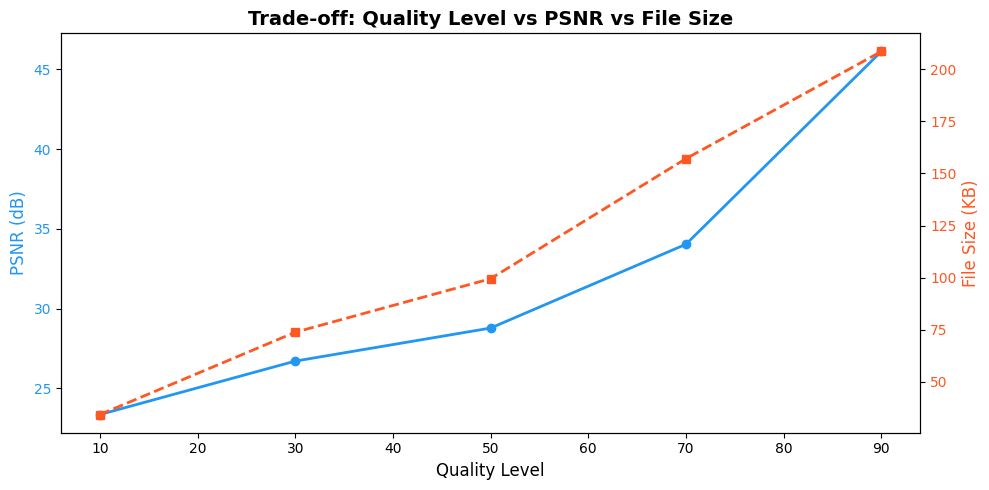

In [26]:
 ## 5. Perbandingan Multi-Quality
#
# Membandingkan efek berbagai level quality (10, 30, 50, 70, 90)
# terhadap ukuran file dan kualitas gambar pada satu sampel.
# Ini menunjukkan **trade-off** utama dalam kompresi lossy.

# %%
# =========================================
# PERBANDINGAN MULTI-QUALITY LEVEL
# =========================================

# FIX: Define sample_files
sample_files = [f for f in os.listdir(INPUT_FOLDER) if Path(f).suffix.lower() in SUPPORTED_EXT]

# Ensure there is at least one sample file
if not sample_files:
    raise FileNotFoundError(f"No supported image files found in {INPUT_FOLDER} for multi-quality comparison.")

sample_path = os.path.join(INPUT_FOLDER, sample_files[0])
orig_img = np.array(Image.open(sample_path).convert("RGB"))
orig_size = os.path.getsize(sample_path) / 1024

mq_results = []

for q in QUALITY_LEVELS:
    temp_path = os.path.join(OUTPUT_FOLDER, f"temp_q{q}.jpg")
    Image.open(sample_path).convert("RGB").save(
        temp_path, "JPEG", optimize=True, quality=q)

    c_size = os.path.getsize(temp_path) / 1024
    c_img = np.array(Image.open(temp_path).convert("RGB").resize(
        Image.open(sample_path).size, Image.LANCZOS))

    mq_results.append({
        "Quality": q,
        "Size (KB)": round(c_size, 2),
        "Reduction (%)": round((1 - c_size/orig_size) * 100, 2),
        "PSNR (dB)": round(calc_psnr(orig_img, c_img), 2),
        "SSIM": round(calc_ssim(orig_img, c_img, channel_axis=2), 4)
    })

df_mq = pd.DataFrame(mq_results)
print(f"Sampel: {sample_files[0]} (Original: {orig_size:.2f} KB)\n")
print(df_mq.to_string(index=False))

# Visualisasi trade-off Quality vs PSNR vs Size
fig, ax1 = plt.subplots(figsize=(10, 5))
color1, color2 = '#2196F3', '#FF5722'

ax1.set_xlabel('Quality Level', fontsize=12)
ax1.set_ylabel('PSNR (dB)', color=color1, fontsize=12)
ax1.plot(df_mq['Quality'], df_mq['PSNR (dB)'], 'o-', color=color1, linewidth=2, label='PSNR')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel('File Size (KB)', color=color2, fontsize=12)
ax2.plot(df_mq['Quality'], df_mq['Size (KB)'], 's--', color=color2, linewidth=2, label='Size')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trade-off: Quality Level vs PSNR vs File Size', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

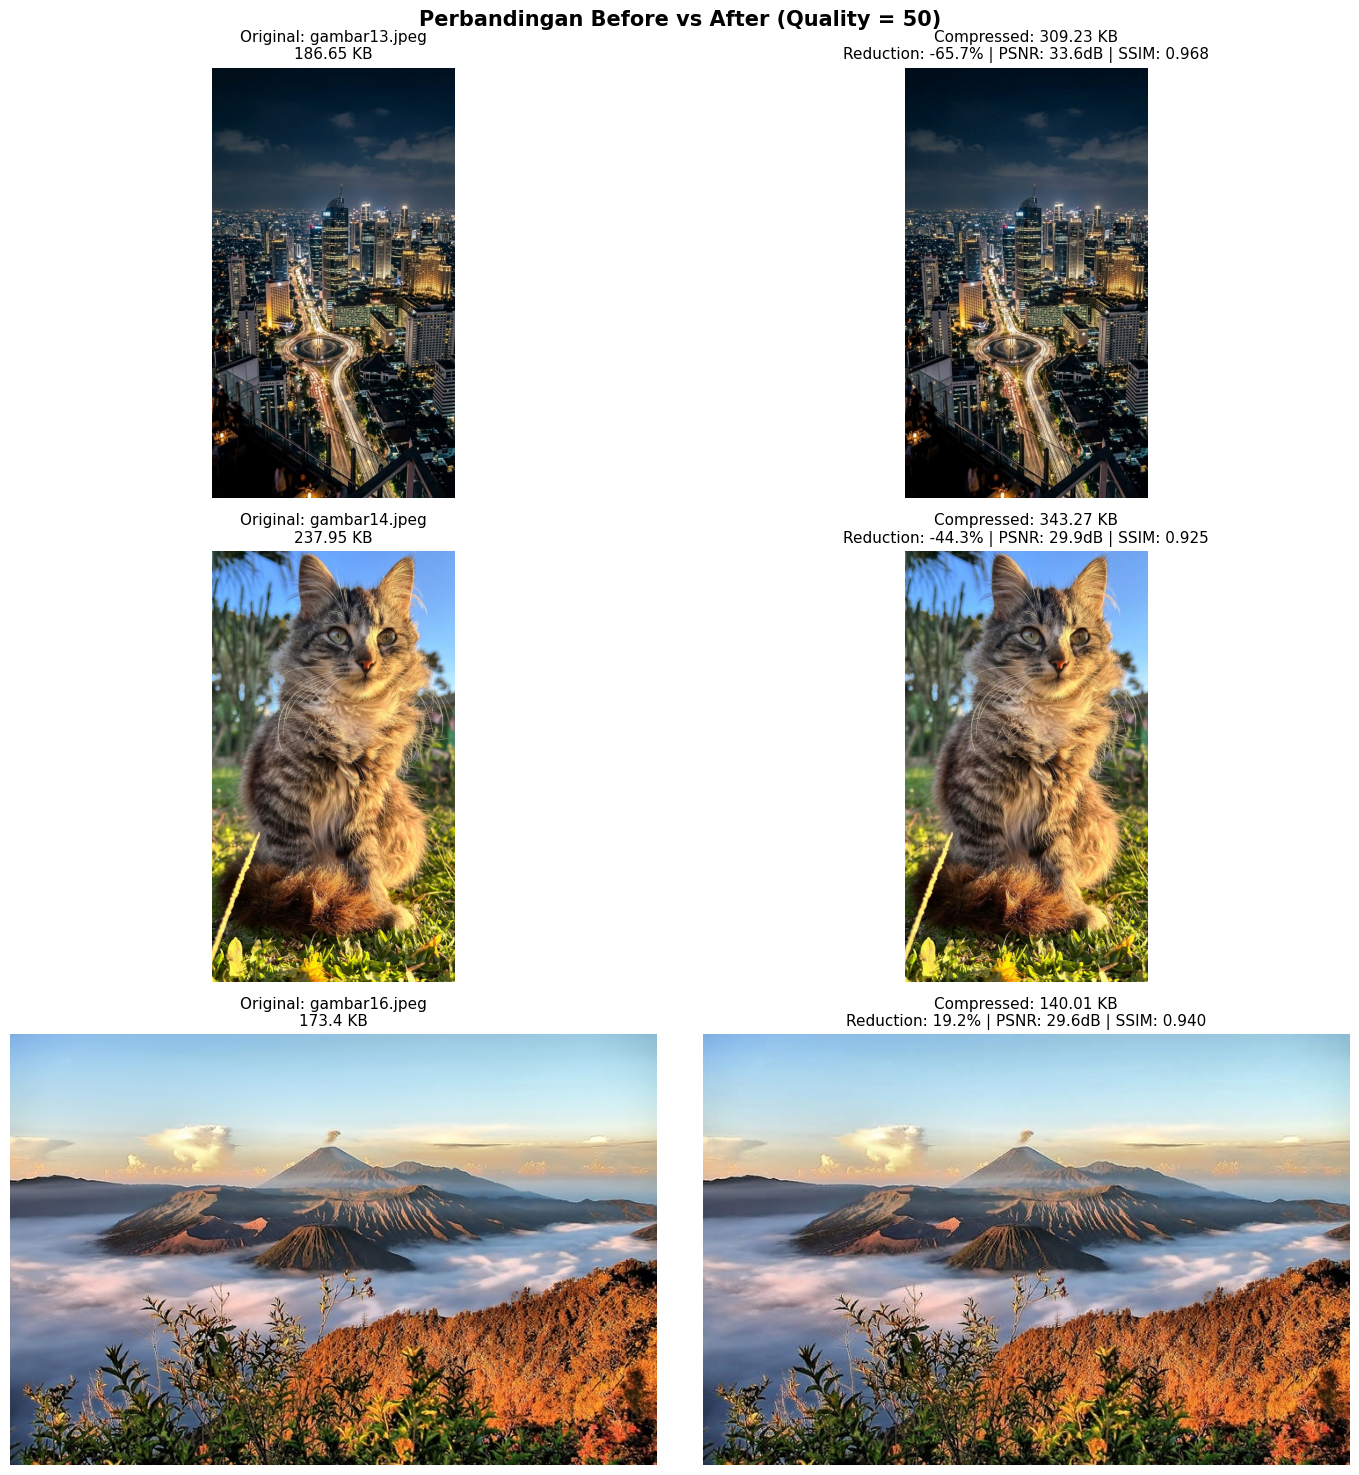

In [27]:
# =========================================
# VISUALISASI : BEFORE vs AFTER (3 SAMPEL)
# =========================================

# Pilih 3 gambar: rasio terkecil, median, terbesar
df_s = df.sort_values('Reduction (%)').reset_index(drop=True)
indices = [0, len(df_s)//2, len(df_s)-1]

fig, axes = plt.subplots(len(indices), 2, figsize=(14, 5*len(indices)))

for row, idx in enumerate(indices):
    info = df_s.iloc[idx]
    inp = os.path.join(INPUT_FOLDER, info['Image'])
    out_name = f"compressed_{Path(info['Image']).stem}.jpg"
    out = os.path.join(OUTPUT_FOLDER, out_name)

    orig = Image.open(inp).convert("RGB")
    comp = Image.open(out).convert("RGB")

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"Original: {info['Image']}\n{info['Original Size (KB)']} KB", fontsize=11)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(comp)
    axes[row, 1].set_title(
        f"Compressed: {info['Compressed Size (KB)']} KB\n"
        f"Reduction: {info['Reduction (%)']:.1f}% | "
        f"PSNR: {info['PSNR (dB)']:.1f}dB | SSIM: {info['SSIM']:.3f}",
        fontsize=11)
    axes[row, 1].axis('off')

plt.suptitle(f'Perbandingan Before vs After (Quality = {DEFAULT_QUALITY})',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [29]:
# ========================================
# SIMPAN HASIL KE CSV
# =========================================

csv_path = os.path.join(RESULTS_FOLDER, "compression_results.csv")
df.to_csv(csv_path, index=False)
print(f"[OK] Hasil disimpan ke: {csv_path}")
print(f"     Total data: {len(df)} gambar (tanpa duplikat)\n")
print(df.to_string(index=False))

[OK] Hasil disimpan ke: results/compression_results.csv
     Total data: 20 gambar (tanpa duplikat)

        Image  Original Size (KB)  Compressed Size (KB)  Compression Ratio  Reduction (%)  PSNR (dB)   SSIM
 gambar1.jpeg              167.95                243.45               1.45         -44.96      29.36 0.9379
gambar10.jpeg              154.45                212.96               1.38         -37.88      32.43 0.9203
gambar11.jpeg              200.31                300.77               1.50         -50.15      32.43 0.9537
gambar12.jpeg              205.63                307.83               1.50         -49.70      31.47 0.9300
gambar13.jpeg              186.65                309.23               1.66         -65.68      33.58 0.9680
gambar14.jpeg              237.95                343.27               1.44         -44.26      29.86 0.9247
gambar15.jpeg              205.81                294.07               1.43         -42.88      32.62 0.9339
gambar16.jpeg              173.40  